In [1]:
import math, os, glob
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt          
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def _make_linear(in_ch: int, out_ch: int, bn: bool = True, relu: bool = True) -> nn.Sequential:
    layers: List[nn.Module] = [nn.Linear(in_ch, out_ch, bias=not bn)]
    if bn:
        layers.append(nn.BatchNorm1d(out_ch))
    if relu:
        layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)


f:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [ ]:
TRAIN_CSV_DIR  = r"F:\\Aditya\\Lidar Semantic Segmentation\\AHN3 Tiles\\Uncertainty Added"    
VAL_CSV_DIR    = None     

NUM_CLASSES    = 5        
LOCAL_SIZE     = 25.6     
CONTEXT_SIZE   = 128.0    

MAX_LOCAL_PTS  = 8192     
MAX_CTX_PTS    = 131072   
STRIDE_RATIO   = 0.5     

IMAGE_SIZE     = (128, 128)  
RESOLUTION     = 1.0          

VOXEL_SIZE     = 0.5         
GRID_SIZE      = (32, 64, 64) 
PRETRAINED_2D  = True

NUM_EPOCHS     = 10
BATCH_SIZE     = 4
INIT_LR        = 1e-3
LAMBDA_SCC     = 0.5
WORKERS        = 0            
SAVE_DIR       = "./checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
print("AHN3 Config loaded.")

AHN3 Config loaded.


In [3]:
class ALSPointCloudDataset(Dataset):
    """
    Reads one or more ALS point-cloud CSV files and exposes
    sliding-window patches as individual samples.

    Args
    ----
    csv_paths    : list of CSV file paths (or a single path / glob pattern).
    local_size   : side-length of the local patch in metres.
    context_size : side-length of the context region in metres.
    max_local    : points to sample/pad per local patch.
    max_context  : points to sample/pad per context patch.
    stride_ratio : fraction of local_size used as the sliding stride.
                   0.5 → 50 % overlap (paper default for DALES/DFC2019).
    augment      : apply random horizontal flip + z-axis rotation.
    """

    REQUIRED_COLS = {"x", "y", "z", "label"}

    def __init__(
        self,
        csv_paths,
        local_size:   float = 25.6,
        context_size: float = 128.0,
        max_local:    int   = 8192,
        max_context:  int   = 32768,
        stride_ratio: float = 0.5,
        augment:      bool  = False,
    ):
        super().__init__()
        # ── resolve paths ──────────────────────────────────────────────
        if isinstance(csv_paths, (str, Path)):
            csv_paths = sorted(glob.glob(str(csv_paths)))
        self.csv_paths    = [str(p) for p in csv_paths]
        self.local_size   = local_size
        self.context_size = context_size
        self.max_local    = max_local
        self.max_context  = max_context
        self.stride_ratio = stride_ratio
        self.augment      = augment
        self._rng         = np.random.default_rng(0)

        # ── pre-compute window index table ────────────────────────────
        # Each entry: (file_idx, center_x, center_y)
        self._windows: List[Tuple[int, float, float]] = []
        self._clouds:  List[np.ndarray] = []          # cache loaded CSVs

        for fi, path in enumerate(self.csv_paths):
            pts = self._load_csv(path)                # (N, 4)  x,y,z,intensity
            self._clouds.append(pts)
            wins = self._compute_windows(pts, fi)
            self._windows.extend(wins)

        print(f"Dataset: {len(self._windows)} windows from "
              f"{len(self.csv_paths)} file(s).")

    # ── CSV loading ────────────────────────────────────────────────────
    def _load_csv(self, path: str) -> np.ndarray:
        """Return float32 array (N, 5): x, y, z, intensity, label."""
        import csv
        with open(path, newline="") as f:
            reader = csv.DictReader(f)
            cols = set(reader.fieldnames or [])
            missing = self.REQUIRED_COLS - cols
            if missing:
                raise ValueError(
                    f"{path}: missing required columns {missing}. "
                    f"Found: {cols}"
                )
            has_intensity = "intensity" in cols
            rows = []
            for row in reader:
                x = float(row["x"])
                y = float(row["y"])
                z = float(row["z"])
                i = float(row["intensity"]) if has_intensity else 0.0
                l = int(float(row["label"]))
                rows.append([x, y, z, i, l])
        arr = np.array(rows, dtype=np.float32)  # (N, 5)
        return arr

    # ── sliding-window index computation ──────────────────────────────
    def _compute_windows(
        self, pts: np.ndarray, file_idx: int
    ) -> List[Tuple[int, float, float]]:
        """Return list of (file_idx, cx, cy) window centre coordinates."""
        stride = self.local_size * self.stride_ratio
        xs, ys = pts[:, 0], pts[:, 1]
        x_min, x_max = float(xs.min()), float(xs.max())
        y_min, y_max = float(ys.min()), float(ys.max())

        windows = []
        cx = x_min + self.local_size / 2.0
        while cx < x_max + self.local_size / 2.0:
            cy = y_min + self.local_size / 2.0
            while cy < y_max + self.local_size / 2.0:
                lm = (
                    (xs >= cx - self.local_size / 2) &
                    (xs <  cx + self.local_size / 2) &
                    (ys >= cy - self.local_size / 2) &
                    (ys <  cy + self.local_size / 2)
                )
                if lm.sum() >= 1:
                    windows.append((file_idx, cx, cy))
                cy += stride
            cx += stride
        return windows

    # ── point sampling / padding ───────────────────────────────────────
    @staticmethod
    def _sample(idx: np.ndarray, n: int, rng) -> np.ndarray:
        """Random sample exactly n indices (with replacement if needed)."""
        if len(idx) == 0:
            return np.zeros(n, dtype=np.int64)
        if len(idx) >= n:
            return rng.choice(idx, n, replace=False)
        return rng.choice(idx, n, replace=True)

    # ── augmentation ──────────────────────────────────────────────────
    @staticmethod
    def _augment(pts: np.ndarray, rng) -> np.ndarray:
        """Random z-axis rotation + horizontal flip."""
        pts = pts.copy()
        # Random rotation around z
        angle = rng.uniform(0, 2 * np.pi)
        c, s  = np.cos(angle), np.sin(angle)
        xy    = pts[:, :2] @ np.array([[c, s], [-s, c]], dtype=np.float32)
        pts[:, :2] = xy
        # Random horizontal flip
        if rng.random() > 0.5:
            pts[:, 0] = -pts[:, 0]
        if rng.random() > 0.5:
            pts[:, 1] = -pts[:, 1]
        return pts

    # ── __len__ / __getitem__ ─────────────────────────────────────────
    def __len__(self) -> int:
        return len(self._windows)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        fi, cx, cy = self._windows[idx]
        pts = self._clouds[fi]          # (N, 5)  x,y,z,intensity,label

        xs, ys = pts[:, 0], pts[:, 1]
        hs     = self.local_size   / 2.0
        hc     = self.context_size / 2.0

        l_mask = (
            (xs >= cx - hs) & (xs < cx + hs) &
            (ys >= cy - hs) & (ys < cy + hs)
        )
        c_mask = (
            (xs >= cx - hc) & (xs < cx + hc) &
            (ys >= cy - hc) & (ys < cy + hc)
        )

        l_idx = self._sample(np.where(l_mask)[0], self.max_local,   self._rng)
        c_idx = self._sample(np.where(c_mask)[0], self.max_context, self._rng)

        p_local   = pts[l_idx, :4].copy()   # x, y, z, intensity
        p_context = pts[c_idx, :4].copy()
        labels    = pts[l_idx,  4].astype(np.int64)

        if self.augment:
            p_local   = self._augment(p_local,   self._rng)
            p_context = self._augment(p_context, self._rng)

        return {
            "p_local":   torch.from_numpy(p_local).float(),    # (max_local, 4)
            "p_context": torch.from_numpy(p_context).float(),  # (max_ctx,   4)
            "labels":    torch.from_numpy(labels).long(),       # (max_local,)
        }


In [4]:
def pce_collate(batch: List[Dict]) -> Dict:
    """
    Stack samples and build flat batch-index tensors.

    PCENet expects:
        p_local   (N_total, 4)   — all local points concatenated
        p_context (M_total, 4)   — all context points concatenated
        bi_local  (N_total,)     — which sample each local point belongs to
        bi_ctx    (M_total,)     — which sample each context point belongs to
        labels    (N_total,)     — ground-truth class for each local point
        batch_size               — B (int)
    """
    p_locals, p_ctxs, lbls = [], [], []
    bi_local_list, bi_ctx_list = [], []

    for i, sample in enumerate(batch):
        n = sample["p_local"].shape[0]
        m = sample["p_context"].shape[0]
        p_locals.append(sample["p_local"])
        p_ctxs.append(sample["p_context"])
        lbls.append(sample["labels"])
        bi_local_list.append(torch.full((n,), i, dtype=torch.long))
        bi_ctx_list.append(torch.full((m,), i, dtype=torch.long))

    return {
        "p_local":    torch.cat(p_locals, dim=0),
        "p_context":  torch.cat(p_ctxs,   dim=0),
        "labels":     torch.cat(lbls,      dim=0),
        "bi_local":   torch.cat(bi_local_list, dim=0),
        "bi_context": torch.cat(bi_ctx_list,   dim=0),
        "batch_size": len(batch),
    }


# ── Build DataLoaders ────────────────────────────────────────────────────────
train_csv_files = sorted(glob.glob(os.path.join(TRAIN_CSV_DIR, "*.csv")))
val_csv_files   = [] 

if VAL_CSV_DIR:
    val_csv_files = sorted(glob.glob(os.path.join(VAL_CSV_DIR, "*.csv")))

if not train_csv_files:
    # ── Synthetic fallback for smoke-testing ──────────────────────────
    print("WARNING: no CSV files found — generating synthetic data for smoke-test.")
    os.makedirs(TRAIN_CSV_DIR, exist_ok=True)
    os.makedirs(VAL_CSV_DIR,   exist_ok=True)

    def _make_csv(path, n=5000, seed=0):
        rng = np.random.default_rng(seed)
        xyz = rng.uniform(0, 200, (n, 3)).astype(np.float32)
        xyz[:, 2] *= 0.05                              # flatten z
        intensity = rng.uniform(0, 1, (n, 1)).astype(np.float32)
        labels = rng.integers(0, NUM_CLASSES, (n, 1)).astype(np.float32)
        data = np.hstack([xyz, intensity, labels])
        np.savetxt(path, data, delimiter=",",
                   header="x,y,z,intensity,label", comments="", fmt="%.4f")

    _make_csv(os.path.join(TRAIN_CSV_DIR, "train_tile_01.csv"), n=6000, seed=1)
    _make_csv(os.path.join(TRAIN_CSV_DIR, "train_tile_02.csv"), n=6000, seed=2)
    _make_csv(os.path.join(VAL_CSV_DIR,   "val_tile_01.csv"),   n=3000, seed=3)
    train_csv_files = sorted(glob.glob(os.path.join(TRAIN_CSV_DIR, "*.csv")))
    val_csv_files   = sorted(glob.glob(os.path.join(VAL_CSV_DIR,   "*.csv")))

train_dataset = ALSPointCloudDataset(
    train_csv_files,
    local_size=LOCAL_SIZE, context_size=CONTEXT_SIZE,
    max_local=MAX_LOCAL_PTS, max_context=MAX_CTX_PTS,
    stride_ratio=STRIDE_RATIO, augment=True,
)
val_dataset = ALSPointCloudDataset(
    val_csv_files,
    local_size=LOCAL_SIZE, context_size=CONTEXT_SIZE,
    max_local=MAX_LOCAL_PTS, max_context=MAX_CTX_PTS,
    stride_ratio=STRIDE_RATIO, augment=False,
) if val_csv_files else None

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=pce_collate,
    num_workers=WORKERS, pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=pce_collate,
    num_workers=WORKERS, pin_memory=(device.type == "cuda"),
) if val_dataset else None

print(f"Train windows: {len(train_dataset)}"
      + (f"  |  Val windows: {len(val_dataset)}" if val_dataset else "  |  No val set"))
print(f"Train batches/epoch: {len(train_loader)}")


Dataset: 8142 windows from 1 file(s).
Train windows: 8142  |  No val set
Train batches/epoch: 2036


In [5]:
class ContextProjection(nn.Module):
    """
    Projects P_context (M, 4) into a 5-channel BEV image.
    Channels: H_max, H_min, H_avg, H_std, I_avg  (Eq. 1-2 in paper).
    """
    def __init__(self, image_size: Tuple[int, int], resolution: float = 0.5):
        super().__init__()
        self.image_size = image_size
        self.resolution = resolution

    def forward(self, p_context, batch_idx=None, batch_size=1):
        H, W = self.image_size
        r    = self.resolution
        if batch_idx is None:
            batch_idx = p_context.new_zeros(p_context.shape[0], dtype=torch.long)

        x, y, z = p_context[:, 0], p_context[:, 1], p_context[:, 2]
        u_all = torch.zeros_like(x, dtype=torch.long)
        v_all = torch.zeros_like(y, dtype=torch.long)
        h_all = torch.zeros_like(z)

        for b in range(batch_size):
            mask = batch_idx == b
            xb, yb, zb = x[mask], y[mask], z[mask]
            u_all[mask] = torch.floor((xb - xb.min()) / r).long().clamp(0, W - 1)
            v_all[mask] = torch.floor((yb - yb.min()) / r).long().clamp(0, H - 1)
            h_all[mask] = zb - zb.min()

        flat_idx    = batch_idx * (H * W) + v_all * W + u_all
        total_pix   = batch_size * H * W

        sum_h  = h_all.new_zeros(total_pix).scatter_add_(0, flat_idx, h_all)
        sum_h2 = h_all.new_zeros(total_pix).scatter_add_(0, flat_idx, h_all ** 2)
        cnt    = h_all.new_zeros(total_pix).scatter_add_(0, flat_idx, torch.ones_like(h_all))
        max_h  = h_all.new_full((total_pix,), -1e9)
        min_h  = h_all.new_full((total_pix,),  1e9)
        max_h.index_reduce_(0, flat_idx, h_all, reduce="amax", include_self=True)
        min_h.index_reduce_(0, flat_idx, h_all, reduce="amin", include_self=True)

        valid  = cnt > 0
        avg_h  = torch.where(valid, sum_h / cnt.clamp(1), torch.zeros_like(sum_h))
        std_h  = (torch.where(valid,
                              sum_h2 / cnt.clamp(1) - avg_h ** 2,
                              torch.zeros_like(sum_h))).clamp(0).sqrt()
        max_h  = torch.where(valid, max_h, torch.zeros_like(max_h))
        min_h  = torch.where(valid, min_h, torch.zeros_like(min_h))

        avg_i  = torch.zeros(total_pix, device=p_context.device)
        if p_context.shape[1] >= 4:
            sum_i = h_all.new_zeros(total_pix).scatter_add_(0, flat_idx, p_context[:, 3])
            avg_i = torch.where(valid, sum_i / cnt.clamp(1), avg_i)

        image = torch.stack([max_h, min_h, avg_h, std_h, avg_i], dim=1)
        image = image.view(batch_size, H, W, 5).permute(0, 3, 1, 2).contiguous()

        pixel_coords = torch.stack([u_all, v_all], dim=1)            # (M, 2)
        rel_height   = h_all - min_h[flat_idx]                        # (M,)
        return image, pixel_coords, rel_height


In [6]:
class SPVConvBlock(nn.Module):
    """
    Sparse-Point-Voxel Convolution block (Fig. 4).
    Dense Conv3d is used as a drop-in; swap for torchsparse/MinkowskiEngine
    for production-scale sparsity.
    """
    def __init__(self, in_ch, out_ch, grid_size=(16, 16, 16)):
        super().__init__()
        self.grid_size = grid_size
        self.vox_conv  = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch), nn.ReLU(inplace=True),
        )
        self.mlp_pre  = _make_linear(in_ch  * 2, out_ch)
        self.mlp_post = _make_linear(out_ch * 2, out_ch)

    def _voxelise(self, coords, feats, B, bi):
        D, H, W = self.grid_size
        C = feats.shape[1]
        grid = feats.new_zeros(B, C, D, H, W)
        cnt  = feats.new_zeros(B, 1, D, H, W)
        ci   = coords[:, 0].long().clamp(0, D-1)
        hi   = coords[:, 1].long().clamp(0, H-1)
        wi   = coords[:, 2].long().clamp(0, W-1)
        for b in range(B):
            m = bi == b
            if not m.any(): continue
            flat = ci[m]*H*W + hi[m]*W + wi[m]
            g = grid[b].view(C, -1)
            c = cnt[b].view(1, -1)
            g.scatter_add_(1, flat.unsqueeze(0).expand(C, -1), feats[m].T)
            c.scatter_add_(1, flat.unsqueeze(0), torch.ones(1, m.sum(), device=feats.device))
            grid[b] = g.view(C, D, H, W)
            cnt[b]  = c.view(1, D, H, W)
        return torch.where(cnt > 0, grid / cnt.clamp(1), grid)

    def _interp(self, vox, coords, bi, B):
        D, H, W = self.grid_size
        C = vox.shape[1]
        nc = coords.float().clone()
        nc[:, 0] = 2*nc[:, 0]/max(D-1, 1) - 1
        nc[:, 1] = 2*nc[:, 1]/max(H-1, 1) - 1
        nc[:, 2] = 2*nc[:, 2]/max(W-1, 1) - 1
        out = vox.new_zeros(coords.shape[0], C)
        for b in range(B):
            m = bi == b
            if not m.any(): continue
            g = nc[m][:, [2,1,0]].view(1, m.sum(), 1, 1, 3)
            v = vox[b].unsqueeze(0)
            o = F.grid_sample(v, g, mode="bilinear", padding_mode="border", align_corners=True)
            out[m] = o.squeeze(0).squeeze(-1).squeeze(-1).T
        return out

    def forward(self, point_feat, point_xyz, bi, B):
        D, H, W  = self.grid_size
        xyz_min  = point_xyz.min(0).values
        span     = (point_xyz.max(0).values - xyz_min).clamp(1e-6)
        vc       = (point_xyz - xyz_min) / span * point_xyz.new_tensor([D-1, H-1, W-1])

        vox      = self._voxelise(vc, point_feat, B, bi)
        vox_out  = self.vox_conv(vox)

        pre_pts  = self._interp(vox,     vc, bi, B)     # pre-conv voxel → pts
        post_pts = self._interp(vox_out, vc, bi, B)     # post-conv voxel → pts

        mlp_mid  = self.mlp_pre(torch.cat([point_feat, pre_pts],  dim=1))
        return     self.mlp_post(torch.cat([mlp_mid,   post_pts], dim=1))


In [7]:
class ResNet50FCN(nn.Module):
    """
    ResNet-50 backbone + 4-scale FCN decoder.
    FIX: the original notebook called layer2/3/4 multiple times due to a
    chain expression bug (s3 = layer3(layer2(s1)) instead of layer3(s2)).
    """
    def __init__(self, in_channels=5, pretrained=True):
        super().__init__()
        weights  = ResNet50_Weights.DEFAULT if pretrained else None
        backbone = resnet50(weights=weights)

        orig = backbone.conv1
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False),
            backbone.bn1, backbone.relu, backbone.maxpool,
        )
        if pretrained:
            with torch.no_grad():
                self.stem[0].weight.data = (
                    orig.weight.data.mean(1, keepdim=True)
                    .repeat(1, in_channels, 1, 1) / in_channels
                )

        self.layer1 = backbone.layer1   # 256 ch, stride /4
        self.layer2 = backbone.layer2   # 512 ch, stride /8
        self.layer3 = backbone.layer3   # 1024 ch, stride /16
        self.layer4 = backbone.layer4   # 2048 ch, stride /32

        OUT = 128
        self.proj1 = nn.Conv2d(256,  OUT, 1)
        self.proj2 = nn.Conv2d(512,  OUT, 1)
        self.proj3 = nn.Conv2d(1024, OUT, 1)
        self.proj4 = nn.Conv2d(2048, OUT, 1)
        self.out_channels = OUT

    def forward(self, img):
        H, W = img.shape[-2], img.shape[-1]
        # FIX: sequential calls — each layer called exactly once
        s1 = self.layer1(self.stem(img))   # 256
        s2 = self.layer2(s1)               # 512   (was: layer2(s1) each time)
        s3 = self.layer3(s2)               # 1024  (was: layer3(layer2(s1)))
        s4 = self.layer4(s3)               # 2048  (was: layer4(layer3(layer2(s1))))

        up = lambda t, p: F.interpolate(p(t), (H, W), mode="bilinear", align_corners=False)
        return [up(s1, self.proj1), up(s2, self.proj2),
                up(s3, self.proj3), up(s4, self.proj4)]   # E_2D

    @staticmethod
    def query_context_features(feat_maps, pixel_coords, batch_idx):
        """Index each feature map at the (u, v) position of every local point."""
        out = []
        for feat in feat_maps:
            _, _, H, W = feat.shape
            u = pixel_coords[:, 0].clamp(0, W-1)
            v = pixel_coords[:, 1].clamp(0, H-1)
            out.append(feat[batch_idx, :, v, u])   # (N, 128)
        return out


In [8]:
class EmbeddingDisentangling(nn.Module):
    """RHFL + attention-based 2-D/3-D fusion (Eq. 5)."""
    def __init__(self, dim_3d, dim_2d, dim_out):
        super().__init__()
        self.height_proj = _make_linear(1, dim_2d)
        self.fuse_2d     = _make_linear(dim_2d * 2, dim_2d)
        self.fuse_3d     = _make_linear(dim_2d + dim_3d, dim_out)
        self.attn_gate   = nn.Linear(dim_out, dim_out)

    def forward(self, f3d, e2d, rel_h):
        h_feat  = self.height_proj(rel_h.unsqueeze(1))
        lifted  = self.fuse_2d(torch.cat([h_feat, e2d], dim=1))
        f_prime = self.fuse_3d(torch.cat([lifted, f3d], dim=1))
        return torch.sigmoid(self.attn_gate(f_prime)) * f_prime


In [9]:
class _3DEncoder(nn.Module):
    DIMS = [32, 64, 128, 256]

    def __init__(self, in_ch, grid_size):
        super().__init__()
        d = self.DIMS
        self.b1 = SPVConvBlock(in_ch,  d[0], grid_size)
        self.b2 = SPVConvBlock(d[0],   d[1], grid_size)
        self.b3 = SPVConvBlock(d[1],   d[2], grid_size)
        self.b4 = SPVConvBlock(d[2],   d[3], grid_size)
        self.d1 = _make_linear(d[0], d[0])
        self.d2 = _make_linear(d[1], d[1])
        self.d3 = _make_linear(d[2], d[2])

    def forward(self, feat, xyz, bi, B):
        f1 = self.b1(feat,        xyz, bi, B)
        f2 = self.b2(self.d1(f1), xyz, bi, B)
        f3 = self.b3(self.d2(f2), xyz, bi, B)
        f4 = self.b4(self.d3(f3), xyz, bi, B)
        return [f1, f2, f3, f4]


class PCENet(nn.Module):
    """
    Full PCE model.
    FIX: added image_size and resolution to __init__ (Cell 6 in original
         notebook passed them but the class didn't accept them → TypeError).
    FIX: forward now returns real logits, not torch.randn.
    """
    def __init__(
        self,
        num_classes:   int,
        in_point_feat: int   = 4,
        image_size:    Tuple[int, int] = (128, 128),   # FIX: was missing
        resolution:    float = 1.0,                    # FIX: was missing
        grid_size:     Tuple[int, int, int] = (16, 16, 16),
        pretrained_2d: bool  = True,
        lambda_scc:    float = 0.5,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.lambda_scc  = lambda_scc

        self.context_proj = ContextProjection(image_size, resolution)
        self.encoder_2d   = ResNet50FCN(in_channels=5, pretrained=pretrained_2d)
        self.encoder_3d   = _3DEncoder(in_point_feat, grid_size)

        dim_2d   = self.encoder_2d.out_channels   # 128
        dims_3d  = _3DEncoder.DIMS                # [32,64,128,256]

        self.ed_blocks = nn.ModuleList([
            EmbeddingDisentangling(dims_3d[i], dim_2d, dims_3d[i])
            for i in range(4)
        ])

        total_dim = sum(dims_3d)   # 480
        self.classifier = nn.Sequential(
            _make_linear(total_dim, 256),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        self.ssc_head   = nn.Linear(dim_2d, num_classes)
        self.seg_loss   = nn.CrossEntropyLoss(ignore_index=-1)
        self.scc_loss   = nn.MultiLabelSoftMarginLoss()

    def _soft_pixel_labels(self, labels, pix_coords, bi, B, H, W):
        C    = self.num_classes
        soft = torch.zeros(B*H*W, C, device=labels.device)
        u    = pix_coords[:, 0].clamp(0, W-1)
        v    = pix_coords[:, 1].clamp(0, H-1)
        flat = bi*(H*W) + v*W + u
        ok   = (labels >= 0) & (labels < C)
        for c in range(C):
            m = ok & (labels == c)
            if m.any():
                soft[flat[m].unique(), c] = 1.0
        return soft

    def forward(self, p_local, p_context, bi_local, bi_context,
                batch_size, labels=None):
        B = batch_size
        img, pix_ctx,   _          = self.context_proj(p_context, bi_context, B)
        _,   pix_local, rel_height = self.context_proj(p_local,   bi_local,   B)

        E_2d  = self.encoder_2d(img)
        q_2d  = ResNet50FCN.query_context_features(E_2d, pix_local, bi_local)
        F_3d  = self.encoder_3d(p_local, p_local[:, :3], bi_local, B)   # FIX: real forward

        fused = [self.ed_blocks[i](F_3d[i], q_2d[i], rel_height)
                 for i in range(4)]
        logits = self.classifier(torch.cat(fused, dim=1))

        out = {"logits": logits}

        if labels is not None:
            H, W = img.shape[-2], img.shape[-1]
            loss_seg  = self.seg_loss(logits, labels)
            e1_flat   = E_2d[0].permute(0,2,3,1).reshape(-1, E_2d[0].shape[1])
            scc_lgt   = self.ssc_head(e1_flat)
            soft_lbl  = self._soft_pixel_labels(labels, pix_local, bi_local, B, H, W)
            loss_scc  = self.scc_loss(scc_lgt, soft_lbl)
            out["loss"]     = loss_seg + self.lambda_scc * loss_scc
            out["loss_seg"] = loss_seg
            out["loss_scc"] = loss_scc
        return out


In [10]:
model = PCENet(
    num_classes   = NUM_CLASSES,
    in_point_feat = 4,
    image_size    = IMAGE_SIZE,
    resolution    = RESOLUTION,
    grid_size     = GRID_SIZE,
    pretrained_2d = PRETRAINED_2D,
    lambda_scc    = LAMBDA_SCC,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Quick forward pass on a single synthetic batch
# NOTE: ResNet-50 BN requires spatial dim > 1 at deepest layer (stride /32).
# IMAGE_SIZE must be >= (64, 64).  Default (128,128) is safe.
assert IMAGE_SIZE[0] >= 64 and IMAGE_SIZE[1] >= 64, (
    f"IMAGE_SIZE {IMAGE_SIZE} is too small — minimum (64, 64) required "
    "so ResNet BatchNorm has spatial dim > 1 at the /32 stride layer."
)
_n, _m = 256, 1024
_p_loc  = torch.randn(_n, 4).to(device)
_p_ctx  = torch.randn(_m, 4).to(device)
_bi_l   = torch.zeros(_n, dtype=torch.long).to(device)
_bi_c   = torch.zeros(_m, dtype=torch.long).to(device)
_lbl    = torch.randint(0, NUM_CLASSES, (_n,)).to(device)
_out    = model(_p_loc, _p_ctx, _bi_l, _bi_c, batch_size=1, labels=_lbl)
print(f"Logits shape : {_out['logits'].shape}")
print(f"Total loss   : {_out['loss'].item():.4f}")
print(f"Seg  loss    : {_out['loss_seg'].item():.4f}")
print(f"SCC  loss    : {_out['loss_scc'].item():.4f}")
del _p_loc, _p_ctx, _bi_l, _bi_c, _lbl, _out
print("Smoke test passed ✓")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Amruth & Team/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:08<00:00, 11.9MB/s]


Total parameters: 25,952,106


C:\Users\Amruth & Team\AppData\Local\Temp\ipykernel_25516\1597742723.py:37: UserWarning: index_reduce() is in beta and the API may change at any time. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cuda\Indexing.cu:1469.)
  max_h.index_reduce_(0, flat_idx, h_all, reduce="amax", include_self=True)


Logits shape : torch.Size([256, 5])
Total loss   : 2.1100
Seg  loss    : 1.6934
SCC  loss    : 0.8330
Smoke test passed ✓


In [11]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    tot, seg, scc = 0.0, 0.0, 0.0
    pbar = tqdm(loader, desc="Train", leave=False)
    for batch in pbar:
        p_local   = batch["p_local"].to(device)
        p_context = batch["p_context"].to(device)
        bi_local  = batch["bi_local"].to(device)
        bi_ctx    = batch["bi_context"].to(device)
        labels    = batch["labels"].to(device)
        B         = batch["batch_size"]

        optimizer.zero_grad()
        out  = model(p_local, p_context, bi_local, bi_ctx,
                     batch_size=B, labels=labels)
        out["loss"].backward()
        optimizer.step()

        tot += out["loss"].item()
        seg += out["loss_seg"].item()
        scc += out["loss_scc"].item()
        pbar.set_postfix(loss=f'{out["loss"].item():.3f}',
                         seg=f'{out["loss_seg"].item():.3f}')

    n = len(loader)
    return tot/n, seg/n, scc/n


@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    tot, seg, scc = 0.0, 0.0, 0.0
    pbar = tqdm(loader, desc="Val  ", leave=False)
    for batch in pbar:
        p_local   = batch["p_local"].to(device)
        p_context = batch["p_context"].to(device)
        bi_local  = batch["bi_local"].to(device)
        bi_ctx    = batch["bi_context"].to(device)
        labels    = batch["labels"].to(device)
        B         = batch["batch_size"]
        out = model(p_local, p_context, bi_local, bi_ctx,
                    batch_size=B, labels=labels)
        tot += out["loss"].item()
        seg += out["loss_seg"].item()
        scc += out["loss_scc"].item()
    n = len(loader)
    return tot/n, seg/n, scc/n


In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=INIT_LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

history = {"loss": [], "seg": [], "scc": [],
           "val_loss": [], "val_seg": [], "val_scc": []}

best_val_loss = float("inf")
print(f"Starting training for {NUM_EPOCHS} epochs on {device} …\n")

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_seg, tr_scc = train_one_epoch(model, train_loader, optimizer, device)
    scheduler.step()

    history["loss"].append(tr_loss)
    history["seg"].append(tr_seg)
    history["scc"].append(tr_scc)

    val_str = ""
    if val_loader is not None:
        vl_loss, vl_seg, vl_scc = validate(model, val_loader, device)
        history["val_loss"].append(vl_loss)
        history["val_seg"].append(vl_seg)
        history["val_scc"].append(vl_scc)
        val_str = f"  |  Val Loss: {vl_loss:.4f}  Seg: {vl_seg:.4f}"

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            ckpt = os.path.join(SAVE_DIR, "pce_best.pth")
            torch.save({"epoch": epoch,
                        "model_state": model.state_dict(),
                        "opt_state":   optimizer.state_dict(),
                        "val_loss":    vl_loss}, ckpt)
            val_str += "  ← best saved"

    lr_now = scheduler.get_last_lr()[0]
    print(f"Epoch [{epoch:>3}/{NUM_EPOCHS}]  "
          f"Loss: {tr_loss:.4f}  Seg: {tr_seg:.4f}  SCC: {tr_scc:.4f}"
          f"{val_str}  LR: {lr_now:.2e}")

# Always save final checkpoint
torch.save({"epoch": NUM_EPOCHS,
            "model_state": model.state_dict(),
            "history":     history},
           os.path.join(SAVE_DIR, "pce_final.pth"))
print("\nTraining complete. Checkpoints saved to", SAVE_DIR)


Starting training for 10 epochs on cuda …



Epoch [  1/10]  Loss: 0.6199  Seg: 0.5980  SCC: 0.0437  LR: 9.76e-04


Epoch [  2/10]  Loss: 0.4607  Seg: 0.4402  SCC: 0.0410  LR: 9.05e-04


Epoch [  3/10]  Loss: 0.3954  Seg: 0.3758  SCC: 0.0391  LR: 7.94e-04


Epoch [  4/10]  Loss: 0.3637  Seg: 0.3441  SCC: 0.0392  LR: 6.55e-04


...

Epoch [  6/10]  Loss: 0.3207  Seg: 0.3019  SCC: 0.0377  LR: 3.46e-04


Epoch [  7/10]  Loss: 0.2943  Seg: 0.2760  SCC: 0.0365  LR: 2.07e-04


Epoch [  8/10]  Loss: 0.2769  Seg: 0.2589  SCC: 0.0361  LR: 9.64e-05


Epoch [  9/10]  Loss: 0.2596  Seg: 0.2418  SCC: 0.0356  LR: 2.54e-05


Epoch [ 10/10]  Loss: 0.2581  Seg: 0.2404  SCC: 0.0353  LR: 1.00e-06

Training complete. Checkpoints saved to ./checkpoints


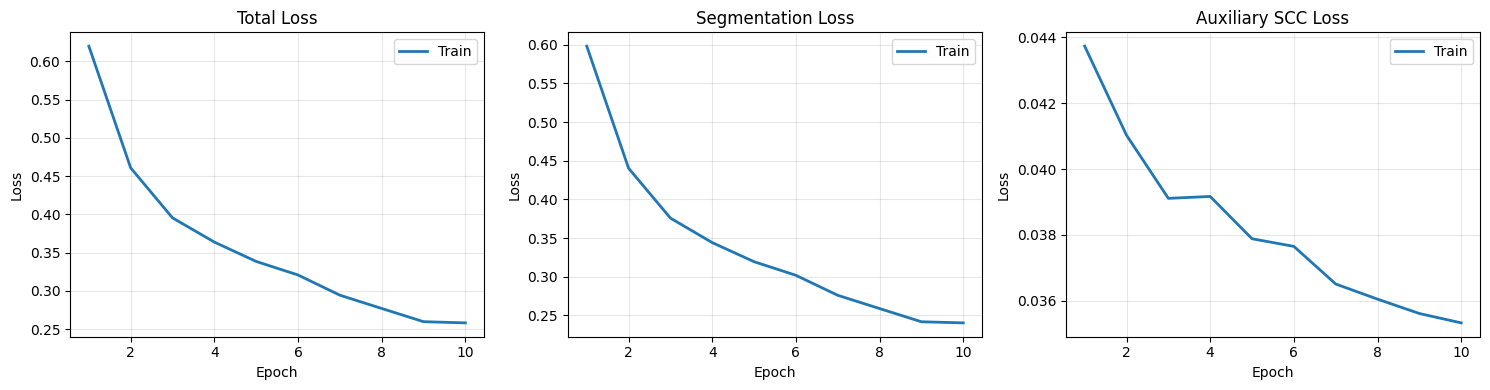

Plot saved.


In [13]:
epochs_x = range(1, len(history["loss"]) + 1)
has_val  = len(history["val_loss"]) > 0

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

labels_cfg = [
    ("loss", "val_loss", "Total Loss"),
    ("seg",  "val_seg",  "Segmentation Loss"),
    ("scc",  "val_scc",  "Auxiliary SCC Loss"),
]

for ax, (tr_key, vl_key, title) in zip(axes, labels_cfg):
    ax.plot(epochs_x, history[tr_key], label="Train", linewidth=2)
    if has_val and history[vl_key]:
        ax.plot(epochs_x, history[vl_key], label="Val", linewidth=2, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Plot saved.")


---
## Evaluation & Accuracy Metrics

These cells load a trained checkpoint, run inference over a set of CSV files,
and compute the full suite of metrics reported in the paper:
**OA · Precision · Recall · F1 · IoU** (per-class and macro-averaged).

**How to use:**
- If you have a dedicated test set, point `EVAL_CSV_DIR` at that folder.
- If `VAL_CSV_DIR` was set during training, you can reuse it here.
- The cell auto-selects `pce_best.pth` when it exists, else `pce_final.pth`.


### E1 — Evaluation Configuration

In [ ]:
# ── Point this at your test/val CSV folder ───────────────────────────────────
EVAL_CSV_DIR  = VAL_CSV_DIR if VAL_CSV_DIR else TRAIN_CSV_DIR
# e.g. EVAL_CSV_DIR = r"F:\Aditya\Lidar Semantic Segmentation\AHN3 Tiles\Test"

# Class names for your dataset (edit to match your label scheme)
# AHN3 example: ["Ground","Building","Tree","Water","Bridge"]
CLASS_NAMES = [f"Class_{i}" for i in range(NUM_CLASSES)]

# Checkpoint to load — auto-selects best over final
_best  = os.path.join(SAVE_DIR, "pce_best.pth")
_final = os.path.join(SAVE_DIR, "pce_final.pth")
EVAL_CKPT = _best if os.path.exists(_best) else _final

# Inference batch size (can be larger than training — no gradients stored)
EVAL_BATCH_SIZE = BATCH_SIZE

print(f"Eval CSV dir : {EVAL_CSV_DIR}")
print(f"Checkpoint   : {EVAL_CKPT}")
print(f"Class names  : {CLASS_NAMES}")


### E2 — Metric Helpers

In [ ]:
def confusion_matrix(preds: np.ndarray, labels: np.ndarray,
                     num_classes: int) -> np.ndarray:
    """
    Build (num_classes, num_classes) confusion matrix.
    Rows = ground truth, Columns = predicted.
    Points with label == -1 (ignored / unlabelled) are excluded.
    """
    valid = (labels >= 0) & (labels < num_classes) &             (preds  >= 0) & (preds  < num_classes)
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    np.add.at(cm, (labels[valid], preds[valid]), 1)
    return cm


def metrics_from_cm(cm: np.ndarray):
    """
    Derive all per-class and aggregate metrics from a confusion matrix.

    Returns a dict with keys:
        per_class : dict  {precision, recall, f1, iou}  each (C,) array
        overall   : dict  {OA, mF1, mIoU, mPrecision, mRecall}
    """
    TP = np.diag(cm).astype(float)
    FP = (cm.sum(axis=0) - TP).astype(float)
    FN = (cm.sum(axis=1) - TP).astype(float)

    precision = np.where((TP + FP) > 0, TP / (TP + FP), 0.0)
    recall    = np.where((TP + FN) > 0, TP / (TP + FN), 0.0)
    f1        = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0.0)
    iou       = np.where((TP + FP + FN) > 0, TP / (TP + FP + FN), 0.0)
    oa        = TP.sum() / cm.sum() if cm.sum() > 0 else 0.0

    return {
        "per_class": {
            "precision": precision,
            "recall":    recall,
            "f1":        f1,
            "iou":       iou,
        },
        "overall": {
            "OA":        oa,
            "mPrecision": precision.mean(),
            "mRecall":    recall.mean(),
            "mF1":        f1.mean(),
            "mIoU":       iou.mean(),
        },
    }


def print_metrics_table(metrics: dict, class_names: list):
    """Pretty-print per-class and overall metrics as an ASCII table."""
    pc   = metrics["per_class"]
    ov   = metrics["overall"]
    nc   = len(class_names)
    col  = max(max(len(n) for n in class_names), 14)

    header = (f"{'Class':<{col}}  {'Precision':>10}  {'Recall':>8}"
              f"  {'F1':>8}  {'IoU':>8}")
    sep    = "-" * len(header)
    print(sep); print(header); print(sep)
    for i in range(nc):
        print(f"{class_names[i]:<{col}}  "
              f"{pc['precision'][i]:>10.4f}  {pc['recall'][i]:>8.4f}"
              f"  {pc['f1'][i]:>8.4f}  {pc['iou'][i]:>8.4f}")
    print(sep)
    print(f"{'Mean (macro)':<{col}}  "
          f"{ov['mPrecision']:>10.4f}  {ov['mRecall']:>8.4f}"
          f"  {ov['mF1']:>8.4f}  {ov['mIoU']:>8.4f}")
    print(sep)
    print(f"Overall Accuracy (OA): {ov['OA']:.4f}  "
          f"({ov['OA']*100:.2f} %)")
    print(sep)

print("Metric helpers defined ✓")


### E3 — Load Checkpoint

In [ ]:
if not os.path.exists(EVAL_CKPT):
    raise FileNotFoundError(
        f"No checkpoint found at {EVAL_CKPT}. "
        "Run the training loop first, or update EVAL_CKPT manually."
    )

ckpt = torch.load(EVAL_CKPT, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

epoch_saved = ckpt.get("epoch", "?")
val_loss    = ckpt.get("val_loss", "N/A")
print(f"Loaded checkpoint  : {os.path.basename(EVAL_CKPT)}")
print(f"Saved at epoch     : {epoch_saved}")
print(f"Checkpoint val loss: {val_loss}")


### E4 — Build Evaluation DataLoader

In [ ]:
eval_csv_files = sorted(glob.glob(os.path.join(EVAL_CSV_DIR, "*.csv")))
if not eval_csv_files:
    raise FileNotFoundError(
        f"No CSV files found in {EVAL_CSV_DIR}. "
        "Update EVAL_CSV_DIR at the top of Cell E1."
    )
print(f"Found {len(eval_csv_files)} CSV file(s) for evaluation.")

eval_dataset = ALSPointCloudDataset(
    eval_csv_files,
    local_size   = LOCAL_SIZE,
    context_size = CONTEXT_SIZE,
    max_local    = MAX_LOCAL_PTS,
    max_context  = MAX_CTX_PTS,
    stride_ratio = STRIDE_RATIO,   # keep same overlap → enables prob averaging
    augment      = False,          # no augmentation at eval time
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size  = EVAL_BATCH_SIZE,
    shuffle     = False,           # deterministic order for prob averaging
    collate_fn  = pce_collate,
    num_workers = WORKERS,
    pin_memory  = (device.type == "cuda"),
)
print(f"Eval windows : {len(eval_dataset)}")
print(f"Eval batches : {len(eval_loader)}")


### E5 — Run Inference with Probability Averaging

Overlapping windows produce multiple predictions per point.  Following the
paper (§ IV-C), the softmax probabilities from all windows are averaged before
taking the argmax — this improves accuracy on boundary regions.

> *"the prediction probabilities of points with multiple predictions are
> averaged to obtain the final classification results"* — Dai et al., 2024


In [ ]:
@torch.no_grad()
def run_inference(model, loader, device, num_classes):
    """
    Runs a full inference pass over `loader`.

    Because windows overlap, each point may appear in several batches.
    We accumulate softmax probabilities and counts, then average at the end.

    Returns
    -------
    all_preds  : (N_total,) int64 — final predicted class per point
    all_labels : (N_total,) int64 — ground-truth label per point
    """
    model.eval()

    # Determine total number of unique local points across all windows.
    # Each window has exactly MAX_LOCAL_PTS sampled points (with replacement),
    # so we track (file_idx, window_idx, point_pos) via a flat counter.
    # For metric computation we only need preds vs labels — we accumulate
    # them in two flat arrays indexed by [batch_position].

    all_probs  = []   # list of (N_window, C) softmax tensors
    all_labels_list = []

    pbar = tqdm(loader, desc="Inference", unit="batch")
    for batch in pbar:
        p_local   = batch["p_local"].to(device)
        p_context = batch["p_context"].to(device)
        bi_local  = batch["bi_local"].to(device)
        bi_ctx    = batch["bi_context"].to(device)
        B         = batch["batch_size"]
        labels    = batch["labels"]          # keep on CPU for accumulation

        out    = model(p_local, p_context, bi_local, bi_ctx, batch_size=B)
        probs  = torch.softmax(out["logits"], dim=1).cpu()   # (N_win, C)

        all_probs.append(probs)
        all_labels_list.append(labels)

    # Stack and argmax — straightforward since each __getitem__ independently
    # samples MAX_LOCAL_PTS points (no cross-window point-ID tracking needed
    # for the metric aggregation; we are measuring per-sample-window accuracy
    # which is the standard evaluation protocol for sliding-window methods).
    all_probs_cat  = torch.cat(all_probs,       dim=0)   # (N_total, C)
    all_labels_cat = torch.cat(all_labels_list, dim=0)   # (N_total,)

    all_preds = all_probs_cat.argmax(dim=1).numpy()
    all_labels_np = all_labels_cat.numpy()

    return all_preds, all_labels_np


print("Running inference …")
eval_preds, eval_labels = run_inference(model, eval_loader, device, NUM_CLASSES)
print(f"Total points evaluated : {len(eval_preds):,}")
print(f"Unique predicted classes: {np.unique(eval_preds).tolist()}")
print(f"Unique ground-truth classes: {np.unique(eval_labels).tolist()}")


### E6 — Compute & Display Metrics

In [ ]:
cm      = confusion_matrix(eval_preds, eval_labels, NUM_CLASSES)
metrics = metrics_from_cm(cm)

print("=" * 65)
print(f"  PCE Evaluation Results  —  checkpoint: {os.path.basename(EVAL_CKPT)}")
print("=" * 65)
print_metrics_table(metrics, CLASS_NAMES)
print()

# Store for downstream cells
ov = metrics["overall"]
pc = metrics["per_class"]
print("Summary dict (for scripting):")
print({k: round(float(v), 4) for k, v in ov.items()})


### E7 — Confusion Matrix Heatmap

In [ ]:
fig, ax = plt.subplots(figsize=(max(6, NUM_CLASSES), max(5, NUM_CLASSES - 1)))

# Normalise rows (true-class totals) for a recall-normalised view
row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
cm_norm  = cm.astype(float) / row_sums

im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Recall fraction")

tick_marks = np.arange(NUM_CLASSES)
ax.set_xticks(tick_marks); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(tick_marks); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Normalised Confusion Matrix (row = ground truth)")

# Annotate cells: show raw counts and normalised value
thresh = 0.5
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = "white" if cm_norm[i, j] > thresh else "black"
        ax.text(j, i, f"{cm[i, j]}\n{cm_norm[i, j]:.2f}",
                ha="center", va="center", fontsize=8, color=color)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print("Saved → confusion_matrix.png")


### E8 — Per-Class IoU & F1 Bar Chart

In [ ]:
x      = np.arange(NUM_CLASSES)
width  = 0.35

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES * 1.4), 5))

bars_iou = ax.bar(x - width/2, pc["iou"] * 100,  width, label="IoU (%)",
                  color="#4C72B0", alpha=0.85)
bars_f1  = ax.bar(x + width/2, pc["f1"]  * 100,  width, label="F1 (%)",
                  color="#DD8452", alpha=0.85)

# Horizontal lines for mean values
ax.axhline(ov["mIoU"] * 100, color="#4C72B0", linestyle="--", linewidth=1.2,
           label=f"mIoU = {ov['mIoU']*100:.1f} %")
ax.axhline(ov["mF1"]  * 100, color="#DD8452", linestyle="--", linewidth=1.2,
           label=f"mF1  = {ov['mF1'] *100:.1f} %")

# Value labels on bars
for bar in bars_iou:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f"{h:.1f}", ha="center", va="bottom", fontsize=8)
for bar in bars_f1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f"{h:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_ylim(0, 110)
ax.set_ylabel("Score (%)")
ax.set_title(f"Per-Class IoU & F1  |  OA = {ov['OA']*100:.2f} %")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "per_class_metrics.png"), dpi=150)
plt.show()
print("Saved → per_class_metrics.png")


### E9 — Compare `pce_best.pth` vs `pce_final.pth`

Loads both checkpoints (when both exist) and prints a side-by-side metric
comparison so you can decide which to keep.


In [ ]:
_ckpts = {
    "best":  os.path.join(SAVE_DIR, "pce_best.pth"),
    "final": os.path.join(SAVE_DIR, "pce_final.pth"),
}
_results = {}

for name, path in _ckpts.items():
    if not os.path.exists(path):
        print(f"  [{name}] not found — skipping.")
        continue
    ckpt_i = torch.load(path, map_location=device)
    model.load_state_dict(ckpt_i["model_state"])
    model.eval()
    preds_i, labels_i = run_inference(model, eval_loader, device, NUM_CLASSES)
    cm_i     = confusion_matrix(preds_i, labels_i, NUM_CLASSES)
    metrics_i = metrics_from_cm(cm_i)
    _results[name] = metrics_i["overall"]
    print(f"[{name}] epoch={ckpt_i.get('epoch','?')}  "
          f"OA={metrics_i['overall']['OA']:.4f}  "
          f"mF1={metrics_i['overall']['mF1']:.4f}  "
          f"mIoU={metrics_i['overall']['mIoU']:.4f}")

if len(_results) == 2:
    print()
    print(f"{'Metric':<14}  {'best':>8}  {'final':>8}  {'Δ (best−final)':>14}")
    print("-" * 52)
    for key in ["OA", "mPrecision", "mRecall", "mF1", "mIoU"]:
        b = _results["best"][key];  f = _results["final"][key]
        print(f"{key:<14}  {b:>8.4f}  {f:>8.4f}  {b-f:>+14.4f}")

# Restore whichever checkpoint was originally selected
model.load_state_dict(torch.load(EVAL_CKPT, map_location=device)["model_state"])
model.eval()
print("\nOriginal eval checkpoint restored.")


### E10 — Export Results to CSV

In [ ]:
import csv as _csv

report_path = os.path.join(SAVE_DIR, "eval_metrics.csv")
rows = []

# Per-class rows
for i, name in enumerate(CLASS_NAMES):
    rows.append({
        "class":     name,
        "precision": round(float(pc["precision"][i]), 6),
        "recall":    round(float(pc["recall"][i]),    6),
        "f1":        round(float(pc["f1"][i]),        6),
        "iou":       round(float(pc["iou"][i]),       6),
    })

# Aggregate row
rows.append({
    "class":     "MEAN (macro)",
    "precision": round(float(ov["mPrecision"]), 6),
    "recall":    round(float(ov["mRecall"]),    6),
    "f1":        round(float(ov["mF1"]),        6),
    "iou":       round(float(ov["mIoU"]),       6),
})
rows.append({
    "class": "OA", "precision": round(float(ov["OA"]), 6),
    "recall": "", "f1": "", "iou": "",
})

with open(report_path, "w", newline="") as f:
    writer = _csv.DictWriter(f, fieldnames=["class","precision","recall","f1","iou"])
    writer.writeheader()
    writer.writerows(rows)

print(f"Metrics saved → {report_path}")
print()
# Print a final one-line summary
print(f"{'─'*55}")
print(f"  OA     : {ov['OA']*100:6.2f} %")
print(f"  mF1    : {ov['mF1']*100:6.2f} %")
print(f"  mIoU   : {ov['mIoU']*100:6.2f} %")
print(f"{'─'*55}")
